In [1]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [2]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    fig, ax = plt.subplots(figsize=(7, 5))
    img = mpimg.imread(filename)
    ax.imshow(img)
    ax.axis('off')
    

print('\nPrinting latex:')
print_tex('\sum_{i=1}^{10} x_i')

print('\nPrinting the result of an evaluated expression:')
print_wlresult(ws.evaluate('x+2+y+3'))

print('\nEvaluating and printing an expression directly:')
print_wlexpr('Sum[x^k, {k, 0, 5}]')

print('\nEvaluating, storing, and printing reults:')
wc('Sum[x^k, {k, 0, 5}]')

print('\nAccessing those results in the variable "rrr":')
wc('rrr*10 + y')


Printing latex:


<IPython.core.display.Math object>


Printing the result of an evaluated expression:


<IPython.core.display.Math object>


Evaluating and printing an expression directly:


...


Evaluating, storing, and printing reults:


<IPython.core.display.Math object>


Accessing those results in the variable "rrr":


<IPython.core.display.Math object>

Plus[Times[10, Plus[1, Global`x, << 2 >>, Power[Global`x, 4], Power[Global`x, 5]]], Global`y]

In [8]:
wc('''
FullSimplify[Integrate[ x*Exp[-I*x*v]*Exp[Pi/2*x] / (Exp[Pi*x] - 1), x]]
''')

<IPython.core.display.Math object>

Times[Power[E, Times[Rational[-1, 2], Plus[Pi, Times[Complex[0, 2], Global`v]], Global`x]], Power[Pi, -2], Plus[Times[-1, Power[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]], << 1 >>, Global`x, Beta[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], 0]], Times[Power[E, Times[Pi, Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]]]]]

In [17]:
wc('''
FullSimplify[Limit[
Power[E, Times[Rational[-1, 2], Plus[Pi, Times[Complex[0, 2], Global`v]], Global`x]]
* Power[E, Times[Pi, x]]
* HurwitzLerchPhi[Power[E, Times[Pi, x]], 2, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], v]]],
x->Infinity]]
''')

String expected at position 1 in StringForm[MessageName[General, msgl], $MessageList].
Undefined message MessageName[Message, msgl] with arguments {$MessageList}
∞ is not a valid variable.
String expected at position 1 in StringForm[MessageName[General, msgl], $MessageList].
Undefined message MessageName[Message, msgl] with arguments {$MessageList}
∞ is not a valid variable.
String expected at position 1 in StringForm[MessageName[General, nord], Times[0 + Abs[0.5]i, Pi]].
Invalid comparison with Times[0 + Abs[0.5]i, Pi] attempted.
String expected at position 1 in StringForm[MessageName[General, nord], Times[0 - Abs[-0.5]i, Pi]].
Invalid comparison with Times[0 - Abs[-0.5]i, Pi] attempted.
String expected at position 1 in StringForm[MessageName[General, nord], Times[0 - Abs[-0.5]i, Pi]].
Invalid comparison with Times[0 - Abs[-0.5]i, Pi] attempted.
String expected at position 1 in StringForm[MessageName[General, msgl], $MessageList].
Undefined message MessageName[Message, msgl] with argu

<IPython.core.display.Math object>

Limit[Times[Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]]], Rule[Global`x, DirectedInfinity[1]]]

In [28]:
wc('''
r1 = Integrate[ x*Exp[-I*x*v]*Exp[Pi/2*x] / (Exp[Pi*x] - 1), x]
''')

<IPython.core.display.Math object>

Times[-2, Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -2], Plus[Times[Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x, Hypergeometric2F1[1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[E, Times[Pi, Global`x]]]], Times[-2, HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), (Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), Power[E, Times[Pi, Global`x]]]]]]

In [29]:
wc('''
r2 = Integrate[ x*Exp[I*x*v]*Exp[Pi/2*x] / (Exp[Pi*x] - 1), x]
''')

<IPython.core.display.Math object>

Times[-2, Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, 2], Global`v]], Global`x]], Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -2], Plus[Times[Plus[Pi, Times[Complex[0, 2], Global`v]], Global`x, Hypergeometric2F1[1, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Power[E, Times[Pi, Global`x]]]], Times[-2, HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]), (Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]), Power[E, Times[Pi, Global`x]]]]]]

In [31]:
wc('''
FullSimplify[r1 + r2]
''')

<IPython.core.display.Math object>

Times[Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], Power[Pi, -2], Plus[Times[-1, Power[Power[E, Times[Pi, Global`x]], Plus[Rational[-1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], << 1 >>, Global`x, Plus[Times[Power[Power[E, Times[Pi, Global`x]], Times[Complex[0, 2], Power[Pi, -1], Global`v]], Beta[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], 0]], Times[Power[E, Times[Complex[0, 2], Global`v, Global`x]], Beta[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], 0]]]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Times[Power[E, Times[Complex[0, 2], Global`v, Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]]]]

In [ ]:
HurwitzLerchPhi[Power[E, Times[Pi, x]], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], v]]]

In [37]:
wc('''
FullSimplify[Limit[HurwitzLerchPhi[Exp[Pi*x], 2, 1/2 + I*v/Pi], 
x->Infinity]]
''')

<IPython.core.display.Math object>

HurwitzLerchPhi[DirectedInfinity[1], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]

In [71]:
wc('''
FullSimplify[MeijerG[{{1}, {3/2+I*v/Pi, 3/2+I*v/Pi}}, {{1, 1/2+I*v/Pi, 1/2+I*v/Pi}, {}}, -Exp[-Pi*x]]
- HurwitzLerchPhi[Exp[Pi*x], 2, 1/2 + I*v/Pi]]
''')

<IPython.core.display.Math object>

0

In [78]:
wc('''
FullSimplify[Exp[Pi*x]*MeijerG[{{1}, {3/2+I*v/Pi, 3/2+I*v/Pi}}, {{1, 1/2+I*v/Pi, 1/2+I*v/Pi}, {}}, -Exp[-Pi*x]]]
''')

<IPython.core.display.Math object>

Times[Power[E, Times[Pi, Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]]

In [80]:
wc('''
FullSimplify[
     Exp[-1/2*(Pi+2*I*v)*x]
   * Exp[Pi*x]
   * MeijerG[{{1}, {3/2+I*v/Pi, 3/2+I*v/Pi}}, {{1, 1/2+I*v/Pi, 1/2+I*v/Pi}, {}}, -Exp[-Pi*x]]
]
''')

<IPython.core.display.Math object>

Times[Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]]

In [85]:
wc('''
FullSimplify[
     Exp[-1/2*(Pi+2*I*v)*x]
   * Exp[Pi*x]
   * MeijerG[{{1}, {3/2+I*v/Pi, 3/2+I*v/Pi}}, {{1, 1/2+I*v/Pi, 1/2+I*v/Pi}, {}}, -Exp[-Pi*x]]
]
''')

<IPython.core.display.Math object>

Times[Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]]

In [91]:
wc('''
FullSimplify[
   Limit[
        Exp[-1/2*(Pi+2*I*v)*x]
        * Exp[Pi*x]
        * MeijerG[{{1}, {3/2+I*v/Pi, 3/2+I*v/Pi}}, {{1, 1/2+I*v/Pi, 1/2+I*v/Pi}, {}}, -Exp[-Pi*x]],
        x-> Infinity
    ]
]
''')

<IPython.core.display.Math object>

Limit[Times[Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]], Rule[Global`x, DirectedInfinity[1]]]

In [92]:
wc('''
FullSimplify[
   Limit[
        MeijerG[{{1}, {3/2+I*v/Pi, 3/2+I*v/Pi}}, {{1, 1/2+I*v/Pi, 1/2+I*v/Pi}, {}}, -Exp[-Pi*x]],
        x-> Infinity
    ]
]
''')

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



<IPython.core.display.Math object>

HurwitzLerchPhi[DirectedInfinity[1], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]

In [93]:
wc('''
FullSimplify[
   Limit[
        x^(j-k)*PolyLog[k+1, Exp[-Pi/2*x]],
        x-> Infinity
    ]
]
''')

<IPython.core.display.Math object>

0

<IPython.core.display.Math object>

<IPython.core.display.Javascript object>


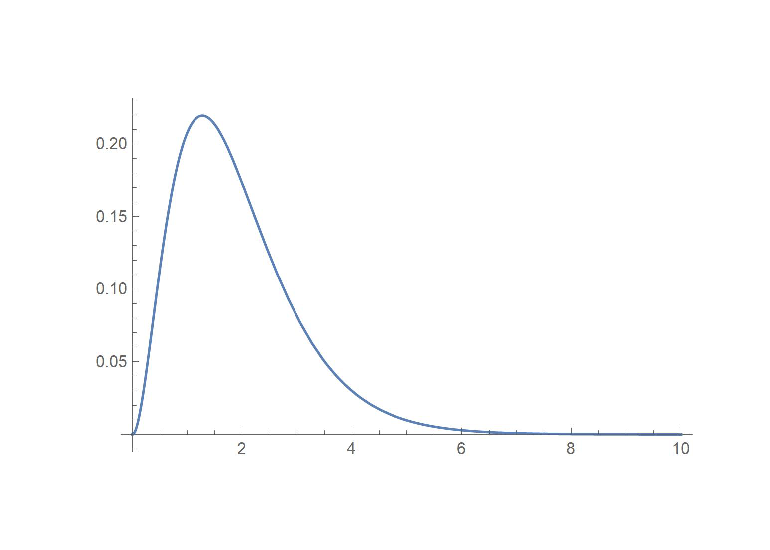

In [116]:
wplot("test1.jpg", '''
j=5;
k=3;
Plot[
x^(j-k)*1/2*(PolyLog[k+1, Exp[-Pi/2*x]] - PolyLog[k+1, -Exp[-Pi/2*x]]), {x, 0, 0}]
''')
    

In [111]:
wc('''
ClearAll[j,k];
FullSimplify[
   Limit[
        x^(j-k)*PolyLog[k+1, -Exp[-Pi/2*x]],
        x-> Infinity
    ]
]
''')

<IPython.core.display.Math object>

0

In [48]:
ws.stop()